# 01 - Datos, EDA y problematicas del dataset

## Resumen amplio

Este notebook convierte SQLite en conocimiento sobre el dataset. El EDA incluye la matriz multietiqueta, comprobaciones de integridad, calidad de datos, distribuciones, coocurrencias y ejemplos reales.

LexGLUE / ECtHR Task B tiene tres rasgos dominantes: es multietiqueta, esta desbalanceado y contiene textos largos. Un pipeline ingenuo puede parecer bueno en micro-F1 mientras falla en etiquetas escasas o genera falsos negativos juridicamente relevantes.

Limitacion importante: la version de Hugging Face usada no expone ano oficial de sentencia. Por eso el analisis posterior se formula como shift entre particiones del benchmark, no como deriva temporal fuerte con fechas reales.

## Indice

1. Carga desde SQLite.
2. Matriz multietiqueta.
3. Verificaciones de integridad.
4. Calidad y completitud.
5. Splits oficiales.
6. Longitud documental.
7. Desbalanceo, cardinalidad y densidad.
8. Prevalencia por split y coocurrencias.
9. Ejemplos reales interpretados.
10. Diagnostico final.


![Esquema especifico generado con Image Gen](artifacts/figures/generated/notebook_01_eda_v2.png)

**Lectura del esquema.** La imagen resume las preguntas del EDA: tamano de splits, longitud de textos, desbalanceo de articulos, coocurrencias y ejemplos reales para interpretar la dificultad del dataset. La imagen es conceptual; las cifras y conclusiones se calculan en las celdas del notebook con datos reales.


In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import project_utils as pu
warnings.filterwarnings('ignore')
pu.configure(); sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 180)

## 1. Carga desde SQLite

Si la base no existe, se reconstruye con `schema.sql`. Despues se cargan las tablas principales y se crea la matriz multietiqueta real `Y`.


In [2]:
pu.materialize_database(force=False)
cases, labels, articles = pu.load_cases_labels()
y = pu.multilabel_matrix(labels, cases['case_id'], articles)
case_label_counts = y.sum(axis=1).rename('n_positive_articles')
eda_base = cases.join(case_label_counts, on='case_id')
shape_summary = pd.DataFrame([{
    'n_cases': len(cases), 'n_articles': len(articles), 'n_positive_pairs': len(labels),
    'mean_labels_per_case': case_label_counts.mean(), 'max_labels_in_case': int(case_label_counts.max()),
    'n_paragraphs': int(cases['n_paragraphs'].sum()), 'missing_official_year': int(cases['year'].isna().sum())}])
display(shape_summary)

,n_cases,n_articles,n_positive_pairs,mean_labels_per_case,max_labels_in_case,n_paragraphs,missing_official_year
0,11000,10,15991,1.453727,7,262580,11000


## 2. Matriz multietiqueta

La matriz `Y` tiene una fila por caso y una columna por articulo. Un `1` significa que LexGLUE marca ese articulo como positivo para el caso. Esta representacion es la base comun del EDA, del modelado y de las metricas.


In [3]:
display(y.head())
display(y.sum(axis=1).describe().to_frame('articulos_positivos_por_caso'))

,2,3,5,6,8,9,10,11,14,P1-1
case_id,,,,,,,,,,
ecthr_task_b_test_000000,0,0,0,0,0,0,1,0,0,0
ecthr_task_b_test_000001,0,0,0,0,1,0,0,0,0,0
ecthr_task_b_test_000002,0,0,0,1,0,0,0,0,0,0
ecthr_task_b_test_000003,0,0,0,1,0,0,0,0,0,0
ecthr_task_b_test_000004,0,1,0,1,0,0,0,0,0,0


,articulos_positivos_por_caso
count,11000.000000
mean,1.453727
std,0.757329
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,7.000000


## 3. Verificaciones de integridad

Estas comprobaciones evitan analizar o entrenar sobre una base corrupta: no debe haber textos vacios, etiquetas huerfanas ni parrafos sin caso. Tambien se valida el volumen real del dataset antes de entrar en distribuciones y ejemplos.


In [4]:
with pu.connect_db() as conn:
    checks = pd.DataFrame([
        {'check':'casos totales','value':conn.execute('SELECT COUNT(*) FROM cases').fetchone()[0]},
        {'check':'casos sin texto','value':conn.execute("SELECT COUNT(*) FROM cases WHERE TRIM(text_full) = ''").fetchone()[0]},
        {'check':'parrafos totales','value':conn.execute('SELECT COUNT(*) FROM case_paragraphs').fetchone()[0]},
        {'check':'articulos catalogados','value':conn.execute('SELECT COUNT(*) FROM articles').fetchone()[0]},
        {'check':'pares positivos caso-articulo','value':conn.execute('SELECT COUNT(*) FROM case_labels').fetchone()[0]},
        {'check':'etiquetas huerfanas','value':conn.execute('SELECT COUNT(*) FROM case_labels cl LEFT JOIN articles a ON a.article_id=cl.article_id WHERE a.article_id IS NULL').fetchone()[0]},
        {'check':'parrafos huerfanos','value':conn.execute('SELECT COUNT(*) FROM case_paragraphs cp LEFT JOIN cases c ON c.case_id=cp.case_id WHERE c.case_id IS NULL').fetchone()[0]},
    ])
    split_counts = pd.read_sql_query('SELECT split, COUNT(*) AS n_cases FROM cases GROUP BY split ORDER BY split', conn)
    article_catalog = pd.read_sql_query('SELECT * FROM articles ORDER BY CAST(article_id AS INTEGER)', conn)
display(checks); display(split_counts); display(article_catalog)

,check,value
0,casos totales,11000
1,casos sin texto,0
2,parrafos totales,262580
3,articulos catalogados,10
4,pares positivos caso-articulo,15991
5,etiquetas huerfanas,0
6,parrafos huerfanos,0


,split,n_cases
0,test,1000
1,train,9000
2,validation,1000


,article_id,article_code,description
0,0,2,Derecho a la vida
1,1,3,Prohibicion de tortura o tratos inhumanos/degradantes
2,2,5,Derecho a la libertad y seguridad
3,3,6,Derecho a un proceso equitativo
4,4,8,Derecho al respeto de la vida privada y familiar
5,5,9,"Libertad de pensamiento, conciencia y religion"
6,6,10,Libertad de expresion
7,7,11,Libertad de reunion y asociacion
8,8,14,Prohibicion de discriminacion
9,9,P1-1,Proteccion de la propiedad


### Interpretacion de las comprobaciones

Estas comprobaciones son parte del trabajo, no una formalidad. Si hubiera etiquetas huerfanas, modelos y metricas no estarian midiendo los articulos esperados. Si hubiera parrafos huerfanos, perderiamos trazabilidad entre el texto original y `text_full`. Si hubiera casos sin texto, el vectorizador podria entrenar sobre ruido.

Tambien se ve que `year` no esta disponible en esta version del dataset. Por rigor, el proyecto no inventa una variable temporal a partir de fechas mencionadas en los hechos, porque esas fechas pueden referirse a sucesos, recursos o informes, no a la fecha de sentencia.


## 4. Calidad de datos

No se fabrican anos a partir del texto: una fecha en los hechos no siempre es fecha de sentencia. Esta decision evita una falsa narrativa de drift temporal.


In [5]:
quality = pd.DataFrame([
    {'aspecto':'casos sin texto','valor':int((cases['text_full'].str.strip()=='').sum())},
    {'aspecto':'casos sin etiquetas positivas','valor':int((case_label_counts==0).sum())},
    {'aspecto':'casos con mas de una etiqueta','valor':int((case_label_counts>1).sum())},
    {'aspecto':'casos sin ano oficial','valor':int(cases['year'].isna().sum())},
    {'aspecto':'tokens minimos','valor':int(cases['n_tokens'].min())},
    {'aspecto':'tokens maximos','valor':int(cases['n_tokens'].max())},
])
display(quality); quality.to_csv(pu.METRICS/'eda_quality_checks.csv', index=False)

,aspecto,valor
0,casos sin texto,0
1,casos sin etiquetas positivas,175
2,casos con mas de una etiqueta,3951
3,casos sin ano oficial,11000
4,tokens minimos,70
5,tokens maximos,35780


## 5. Splits oficiales

`train` se usa para aprender vocabulario, pesos y configuraciones durante el modelado.

La seleccion de hiperparametros se hace despues con `GridSearchCV` y 5 folds sobre `train`.

`validation` queda como split informativo.

`test` se reserva para la evaluacion final.

No se mezclan splits para evitar leakage.


,split,n_cases
0,train,9000
1,validation,1000
2,test,1000


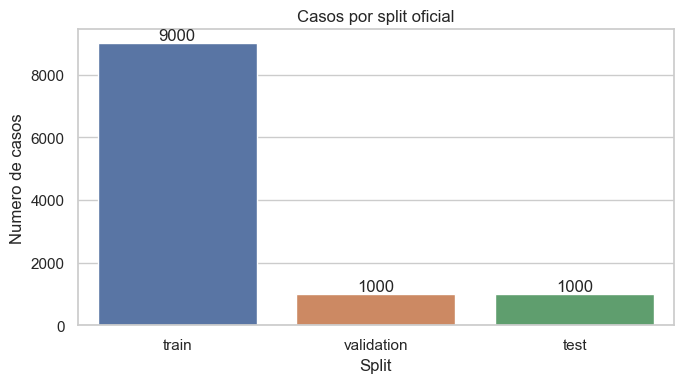

In [6]:
split_counts = cases.groupby('split').size().reindex(pu.SPLIT_ORDER).reset_index(name='n_cases')
split_counts.to_csv(pu.METRICS/'eda_split_counts.csv', index=False)
display(split_counts)
fig, ax = plt.subplots(figsize=(7,4)); sns.barplot(data=split_counts,x='split',y='n_cases',ax=ax,palette='deep')
ax.set_title('Casos por split oficial'); ax.set_xlabel('Split'); ax.set_ylabel('Numero de casos')
for c in ax.containers: ax.bar_label(c, fmt='%d')
fig.tight_layout(); fig.savefig(pu.FIGURES/'eda_split_counts.png', dpi=180); plt.show()

## 6. Longitud documental

Los casos largos hacen arriesgado truncar texto. TF-IDF no tiene el limite de contexto tipico de un transformer generalista, aunque pierde semantica y orden largo.


,split,count,mean,std,min,25%,50%,75%,max
0,train,9000.0,1652.315333,2032.698632,70.0,490.75,1002.5,2033.25,35780.0
1,validation,1000.0,1823.509000,1843.919457,85.0,611.75,1290.5,2377.50,14847.0
2,test,1000.0,1967.142000,1886.732538,104.0,710.75,1441.5,2453.25,16474.0


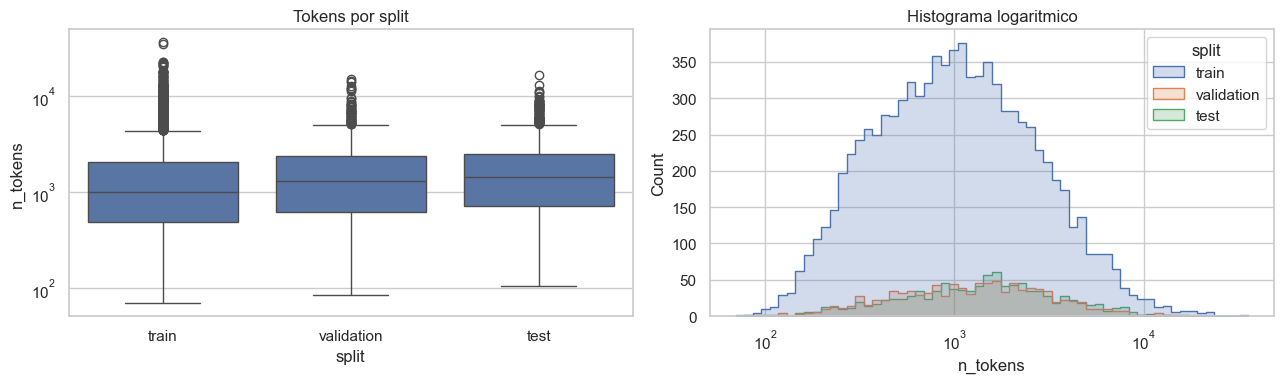

In [7]:
token_stats = cases.groupby('split')['n_tokens'].describe().reindex(pu.SPLIT_ORDER).reset_index()
token_stats.to_csv(pu.METRICS/'eda_token_stats_by_split.csv', index=False); display(token_stats)
fig, axes = plt.subplots(1,2,figsize=(13,4))
sns.boxplot(data=cases,x='split',y='n_tokens',order=pu.SPLIT_ORDER,ax=axes[0]); axes[0].set_yscale('log'); axes[0].set_title('Tokens por split')
sns.histplot(data=cases,x='n_tokens',hue='split',hue_order=pu.SPLIT_ORDER,bins=60,log_scale=True,element='step',ax=axes[1]); axes[1].set_title('Histograma logaritmico')
fig.tight_layout(); fig.savefig(pu.FIGURES/'eda_tokens_by_split.png', dpi=180); plt.show()

## 7. Desbalanceo, cardinalidad y densidad

El desbalanceo afecta a macro-F1; la cardinalidad afecta a cuantos articulos se sugeriran por caso. Ambas cosas son centrales para evaluar un sistema de apoyo juridico.


,article_id,article_code,description,n_cases,prevalence
3,3,6,Derecho a un proceso equitativo,6225,0.565909
1,1,3,Prohibicion de tortura o tratos inhumanos/degradantes,2210,0.200909
2,2,5,Derecho a la libertad y seguridad,2038,0.185273
9,9,P1-1,Proteccion de la propiedad,1881,0.171000
4,4,8,Derecho al respeto de la vida privada y familiar,1397,0.127000
0,0,2,Derecho a la vida,774,0.070364
6,6,10,Libertad de expresion,611,0.055545
8,8,14,Prohibicion de discriminacion,510,0.046364
7,7,11,Libertad de reunion y asociacion,244,0.022182
5,5,9,"Libertad de pensamiento, conciencia y religion",101,0.009182


,label_cardinality_mean,label_cardinality_median,label_density,imbalance_ratio_max_min
0,1.453727,1.0,0.145373,61.633663


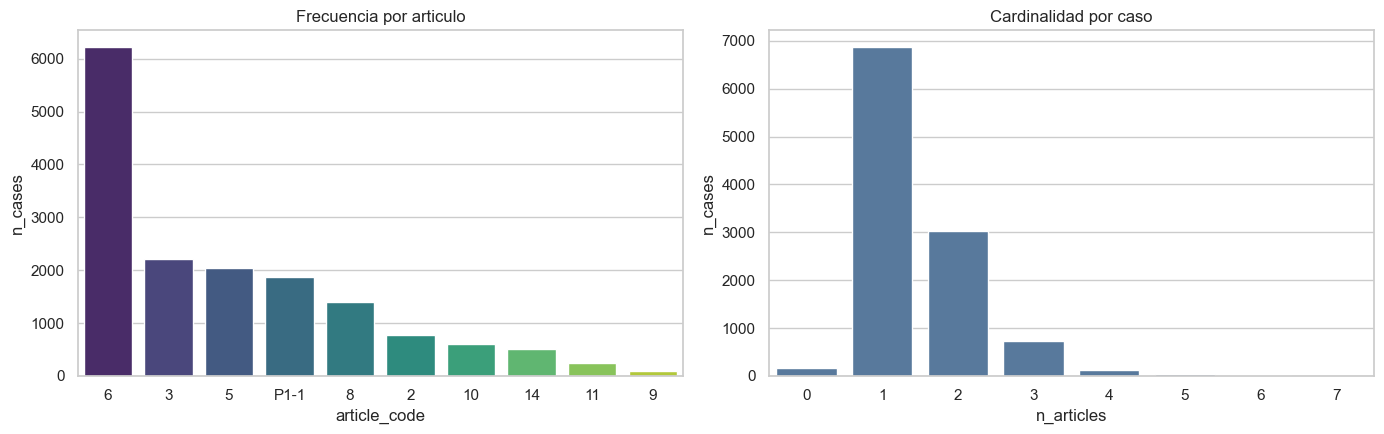

In [8]:
label_freq = labels.merge(articles,on='article_id').groupby(['article_id','article_code','description']).size().reset_index(name='n_cases')
label_freq['prevalence'] = label_freq['n_cases']/len(cases); label_freq = label_freq.sort_values('n_cases', ascending=False)
label_freq.to_csv(pu.METRICS/'eda_top_label_frequency.csv', index=False)
density = pd.DataFrame([{'label_cardinality_mean': y.sum(axis=1).mean(), 'label_cardinality_median': y.sum(axis=1).median(), 'label_density': y.sum(axis=1).mean()/y.shape[1], 'imbalance_ratio_max_min': label_freq['n_cases'].max()/label_freq['n_cases'].min()}])
display(label_freq); display(density); density.to_csv(pu.METRICS/'eda_multilabel_density.csv', index=False)
fig, axes = plt.subplots(1,2,figsize=(14,4.5))
sns.barplot(data=label_freq,x='article_code',y='n_cases',ax=axes[0],palette='viridis'); axes[0].set_title('Frecuencia por articulo')
card = y.sum(axis=1).value_counts().sort_index().reset_index(); card.columns=['n_articles','n_cases']
sns.barplot(data=card,x='n_articles',y='n_cases',ax=axes[1],color='#4c78a8'); axes[1].set_title('Cardinalidad por caso')
fig.tight_layout(); fig.savefig(pu.FIGURES/'eda_label_frequency_cardinality.png', dpi=180); plt.show()

### Interpretacion: por que este EDA condiciona el modelado

La frecuencia por articulo muestra que el problema esta desbalanceado: no todas las etiquetas aportan la misma cantidad de ejemplos positivos. Por eso `accuracy` no seria una metrica adecuada y por eso miramos `macro-F1`: si el sistema falla sistematicamente en articulos raros, macro-F1 lo refleja aunque micro-F1 siga pareciendo aceptable.

La cardinalidad indica cuantos articulos positivos tiene normalmente un caso. Esto importa porque el modelo no debe devolver una sola etiqueta: tiene que poder sugerir varias lineas juridicas candidatas. La densidad multietiqueta resume exactamente esa idea: de las diez posiciones posibles, cuantas suelen estar activas por caso.


In [9]:
most_common = label_freq.iloc[0]
least_common = label_freq.iloc[-1]
cardinality = y.sum(axis=1)

print("Resumen multilabel")
print("==================")
print(f"Articulo mas frecuente : {most_common['article_code']} ({most_common['n_cases']:,.0f} casos)")
print(f"Articulo menos frecuente: {least_common['article_code']} ({least_common['n_cases']:,.0f} casos)")
print(f"Cardinalidad media     : {cardinality.mean():.2f} articulos/caso")
print(f"Longitud maxima        : {cases['n_tokens'].max():,.0f} tokens")

Resumen multilabel
Articulo mas frecuente : 6 (6,225 casos)
Articulo menos frecuente: 9 (101 casos)
Cardinalidad media     : 1.45 articulos/caso
Longitud maxima        : 35,780 tokens


El articulo mas frecuente es 6 con 6225 casos positivos. El menos frecuente es 9 con 101 casos. Esto crea un desbalanceo aproximado de 61.6x entre la etiqueta mayoritaria y la minoritaria.

La cardinalidad media es 1.45 articulos positivos por caso. Por eso el problema es realmente multietiqueta. El sistema debe poder sugerir mas de un articulo. Las metricas deben evaluar cada posicion articulo-caso.

No se plantea reducir la etiqueta 6 eliminando casos como decision principal. Al quitar un caso con articulo 6 tambien se pueden quitar positivos de otros articulos que coocurren en ese mismo caso.

El desbalanceo justifica usar macro-F1 como metrica principal. Tambien justifica usar pesos de clase cuando proceda. La seleccion final de hiperparametros se hace con 5-fold CV sobre train.

La longitud maxima de documento es 35780 tokens. Esta cifra justifica usar una representacion eficiente como TF-IDF.


## 8. Prevalencia por split y coocurrencias

Cambios de prevalencia entre particiones explican variaciones de rendimiento. Las coocurrencias ayudan a interpretar confusiones entre articulos.


split,train,validation,test
article_code,,,
2,0.069222,0.075,0.076
3,0.193333,0.236,0.234
5,0.180333,0.219,0.196
6,0.604111,0.394,0.394
8,0.117333,0.153,0.188
9,0.009000,0.009,0.011
10,0.049000,0.064,0.106
11,0.018000,0.039,0.043
14,0.049333,0.034,0.032


article_code,2,3,5,6,8,9,10,11,14,P1-1
article_code,,,,,,,,,,
2,774,367,261,122,70,3,13,3,58,41
3,367,2210,797,547,312,15,39,36,136,61
5,261,797,2038,570,247,10,37,58,67,40
6,122,547,570,6225,401,22,154,81,191,1290
8,70,312,247,401,1397,22,67,14,202,110
9,3,15,10,22,22,101,21,23,39,6
10,13,39,37,154,67,21,611,54,37,7
11,3,36,58,81,14,23,54,244,38,13
14,58,136,67,191,202,39,37,38,510,80


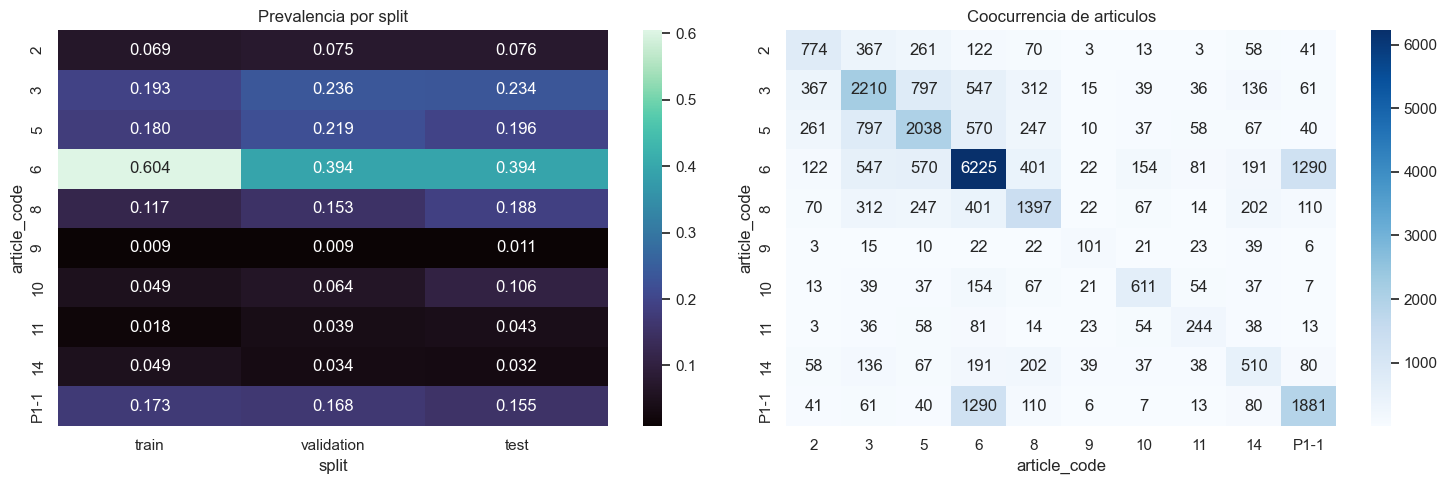

In [10]:
split_label=[]
for split in pu.SPLIT_ORDER:
    ids=cases.loc[cases['split']==split,'case_id']; counts=y.loc[ids].sum(axis=0)
    for article,count in counts.items(): split_label.append({'split':split,'article_code':article,'n_positive':int(count),'prevalence':count/len(ids)})
split_label=pd.DataFrame(split_label); split_label.to_csv(pu.METRICS/'eda_label_by_split.csv', index=False)
heat=split_label.pivot(index='article_code',columns='split',values='prevalence').loc[pu.ARTICLE_CODES,pu.SPLIT_ORDER]
display(heat)
cooc=y.T.dot(y).astype(int); cooc.index.name='article_code'; cooc.to_csv(pu.METRICS/'eda_label_cooccurrence.csv'); display(cooc)
fig, axes = plt.subplots(1,2,figsize=(15,5))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='mako', ax=axes[0]); axes[0].set_title('Prevalencia por split')
sns.heatmap(cooc, annot=True, fmt='d', cmap='Blues', ax=axes[1]); axes[1].set_title('Coocurrencia de articulos')
fig.tight_layout(); fig.savefig(pu.FIGURES/'eda_label_prevalence_and_cooccurrence.png', dpi=180); fig.savefig(pu.FIGURES/'eda_label_cooccurrence.png', dpi=180); plt.show()

### Interpretacion: que aporta la coocurrencia

La matriz de coocurrencia no se usa directamente para entrenar los clasificadores, pero ayuda a leer errores. Si dos articulos aparecen juntos a menudo, un falso positivo puede ser una confusion comprensible por solapamiento tematico. Si apenas coocurren, conviene revisar si el modelo esta aprendiendo atajos del vocabulario.

La diagonal cuenta apariciones individuales; las celdas fuera de la diagonal cuentan apariciones conjuntas. Por eso no se interpreta como correlacion causal entre articulos, sino como una descripcion empirica del dataset.


## 9. Ejemplos interpretados

Estas tablas muestran casos con muchas etiquetas, casos largos, articulo 9 y P1-1.


In [11]:
examples = pu.example_cases()
for name, df in examples.items():
    print(f'\n### {name}')
    display(df)


### most_labels


,case_id,split,year,n_tokens,n_labels,article_codes,excerpt
0,ecthr_task_b_train_004673,train,None,3738,7,"3, 5, 6, 8, 11, 14, P1-1","7. The applicant was born in 1939 and lives in Nicosia. 8. The applicant claimed that her former husband, Mr Ioannis Vrahimis, had been the director and shareholder of a com..."
1,ecthr_task_b_train_004661,train,None,3326,7,"3, 5, 6, 8, 11, 14, P1-1",7. The applicant was born in 1964 and lives in Larnaca. 8. The applicant claimed that his home had been in the village of Marathovounos in the District of Famagusta (norther...
2,ecthr_task_b_train_004815,train,None,2951,7,"3, 5, 6, 8, 11, 14, P1-1",7. The applicant was born in 1950 and lives in Nicosia. 8. The applicant claimed that she had had her home as well as other immovable property in the occupied part of Nicosi...
3,ecthr_task_b_train_004669,train,None,2386,7,"3, 5, 6, 8, 11, 14, P1-1","7. The applicant was born in 1933 and lives in Limassol. 8. The applicant claimed that in 1952, when she was 19 years' old, she had permanently settled in Famagusta (norther..."
4,ecthr_task_b_train_000951,train,None,7113,6,"2, 3, 5, 8, 10, 14","10. The applicants are six women from northern Iraq, born in 1950, 1970, 1951, 1939, 1949 and 1947 respectively. The first applicant brought the application on her own behalf ..."
5,ecthr_task_b_train_000826,train,None,6522,6,"2, 3, 5, 8, 9, 14",9. The applicants were born in 1933 and 1974 respectively and live in Diyarbakır. 10. The facts surrounding the arrest and subsequent death of Mehmet Şah İkincisoy (“Mehmet ...
6,ecthr_task_b_train_000920,train,None,3749,6,"3, 5, 6, 8, 14, P1-1","9. The applicant was born in 1952 and lives in Switzerland. Until December 1993 she lived in the Düzcealan village, attached to the Tatvan District in the province of Bitlis. ..."
7,ecthr_task_b_train_000761,train,None,3453,6,"3, 5, 6, 8, 14, P1-1","9. The applicant was born in 1933 and lives in Diyarbakır. Until the end of 1993, the applicant lived in the village of Akdoruk, attached to the Kulp District in the province ..."



### longest


,case_id,split,year,n_paragraphs,n_tokens,excerpt
0,ecthr_task_b_train_000588,train,None,558,35780,10. The case concerns events in November and December 1993 when the applicants were taken into custody for questioning about their alleged links with the PKK (the Kurdish Work...
1,ecthr_task_b_train_007600,train,None,370,34258,7. Mr Khodorkovskiy (the first applicant) was born in 1963. He is currently serving a prison sentence in a penal colony in the Karelia Region. Mr Lebedev (the second applicant...
2,ecthr_task_b_train_006273,train,None,301,22589,"6. The applicant, OAO Neftyanaya Kompaniya YUKOS, was a publicly-traded private open joint-stock company incorporated under the laws of Russia. It was registered in Nefteyugan..."
3,ecthr_task_b_train_008750,train,None,138,22499,"7. Although the present case primarily relates to the anti-riot operation of 26 September 1999, that operation in fact constituted the climax of a series of long-standing conf..."
4,ecthr_task_b_train_001122,train,None,201,22106,"52. The applicants, Mr Abdul-Vakhab Shamayev, Mr Rizvan (or Rezvan) Vissitov, Mr Khusein Aziev, Mr Adlan (or Aslan) Adayev (or Adiev), Mr Khusein Khadjiev, Mr Ruslan Gelogayev..."
5,ecthr_task_b_train_004636,train,None,71,21692,"7. “Teleradio-Moldova” (TRM) was created by Presidential decree as a State-owned company on 11 March 1994, out of the previously existing State broadcasting body. TRM's statut..."
6,ecthr_task_b_train_000375,train,None,235,21283,"11. The applicant was born in 1973 and lives in Derik, Turkey. 12. The case concerns the circumstances of the death of the applicant's brother, Mr Yakup Aktaş. According to ..."
7,ecthr_task_b_train_005125,train,None,91,20760,"9. The facts of the case and the relevant legal framework may be summarised as follows. 10. On 20 March 2003 a coalition of armed forces (the Multinational Force or “MNF”), ..."



### rare_article_9


,case_id,split,year,n_tokens,article_code,excerpt
0,ecthr_task_b_train_008242,train,None,9495,9,"5. The applicants are all Jehovah’s Witnesses, except for the ninth applicant, M. Kvergelidze. Their application to the Court is based on thirty cases of alleged violence and ..."
1,ecthr_task_b_train_007367,train,None,9193,9,5. The applicants were born in 1964 and 1972 respectively. The first applicant’s whereabouts are unknown. The second applicant lives in Tyumen. 6. The applicants are members...
2,ecthr_task_b_train_008094,train,None,8351,9,12. The applicant was born in 1937 and lives in Cieza. He is married and the father of five children. 13. He was ordained as a priest in 1961. In 1984 he applied to the Vati...
3,ecthr_task_b_validation_000022,validation,None,7730,9,8. The applicant is a Moldovan national belonging to the German ethnic minority. He was born in 1978 and lived in Tiraspol until 2010. Since 2011 he has been an asylum-seeker ...
4,ecthr_task_b_test_000282,test,None,6679,9,"5. The applicant was born in 1973. She grew up in Šiauliai, which in 2003, the time relevant in this case, had about 130,000 inhabitants. She currently lives in Vilnius. 6. ..."



### property_article


,case_id,split,year,n_tokens,article_code,excerpt
0,ecthr_task_b_train_007600,train,None,34258,P1-1,7. Mr Khodorkovskiy (the first applicant) was born in 1963. He is currently serving a prison sentence in a penal colony in the Karelia Region. Mr Lebedev (the second applicant...
1,ecthr_task_b_train_006273,train,None,22589,P1-1,"6. The applicant, OAO Neftyanaya Kompaniya YUKOS, was a publicly-traded private open joint-stock company incorporated under the laws of Russia. It was registered in Nefteyugan..."
2,ecthr_task_b_train_008750,train,None,22499,P1-1,"7. Although the present case primarily relates to the anti-riot operation of 26 September 1999, that operation in fact constituted the climax of a series of long-standing conf..."
3,ecthr_task_b_train_005568,train,None,17632,P1-1,"7. The applicant was born in 1950 and lives in Grozny. 8. According to the applicant, he experiences difficulties in reconstructing the events during and following his deten..."
4,ecthr_task_b_train_006075,train,None,14986,P1-1,7. The applicants are residents of the town of Urus-Martan in the Chechen Republic. 8. At the material time all the applicants lived at various addresses in Urus-Martan. 9....


## 10. Diagnostico final

El dataset cumple la exigencia de miles de instancias y complejidad suficiente. Las problematicas relevantes son explicabilidad, shift entre particiones, desbalanceo, errores FP/FN y privacidad como consideracion de despliegue. La falta de ano oficial se documenta como limitacion metodologica.


## Nota de reproducibilidad

Antes de la entrega final se recomienda ejecutar los notebooks en orden.

Esto regenera salidas y metadatos de ejecucion.
